# Wizard RL — Experiments

Launch the ablation and rebuild the figures from its results.

The five configurations are additive: each adds exactly one axis to the one
before it, so a difference in the outcome is attributable to that axis.

| | bid_mode | value baseline | round sampling | tricks aux | train vs. heuristic |
|---|---|---|---|---|---|
| **A** | policy | off | uniform | off | p_heur = 0 
| **B** | policy | **on** | uniform | off | p_heur = 0
| **C** | policy | on | **r²** | off | p_heur = 0
| **D** | policy | on | r² | **on** | p_heur = 0
| **E** | **ev** | on | r² | on | p_heur = 0
| **F** | ev | on | r² | on |  **p_heur = 0**

`p_heur = 0` for A–E: the story predates heuristic opponents, and mixing them
in would add a variable that is not part of it. F is that variable on its own.

**Every configuration runs under three seeds.** A single run cannot tell a real
effect from a lucky initialisation; the figures show the mean with a min/max
band, the table shows mean +- half the range.

## Setup

In [24]:
import json, os, subprocess, sys, time
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd()
PYTHON = str(REPO / ".wizard_venv" / "bin" / "python")
RESULTS = REPO / "results"
LOGS = REPO / "run_logs"; LOGS.mkdir(exist_ok=True)

sys.path.insert(0, str(REPO))
from train import EXPERIMENTS, Config, load_results
from player import Player, HeuristicAgent, RLAgent
from game import *

for name, cfg in EXPERIMENTS.items():
    if name != "default":
        print(f"{name}: {cfg.run_suffix}")

A: _A_bid-policy_vb-0_rw-0_aux-0.0_ph-0.0
B: _B_bid-policy_vb-1_rw-0_aux-0.0_ph-0.0
C: _C_bid-policy_vb-1_rw-2_aux-0.0_ph-0.0
D: _D_bid-policy_vb-1_rw-2_aux-0.1_ph-0.0
E: _E_bid-ev_vb-1_rw-2_aux-0.1_ph-0.0
F: _F_bid-ev_vb-1_rw-2_aux-0.1_ph-0.4


## 1 — Launch

Make sure to first run all experiments (A - D) over multiple seeds (here: 0, 1, 2) and log results. E.g. via this: 

Navigate to: 
```bash
cd wizard-rl && source .wizard_venv/bin/activate && conda deactivate && which python
```
Run:
```bash
for c in A B C D E F; do
  for s in 1 2; do
    OMP_NUM_THREADS=1 nohup python -u train.py --config $c --seed $s \
        > run_logs/${c}_seed${s}.log 2>&1 &
  done
done



## 2 — Figures

Create Figures and additional analysis.

In [ ]:
SEEDS = (0, 1, 2)          # one seed is not evidence; three shows the spread

def run_id(name, seed):
    """Name of the result file for one (configuration, seed) pair."""
    return f"{name}_seed{seed}"


def series(name, key, seed):
    """One run's curve for one metric."""
    res = load_results(run_id(name, seed), result_dir=str(RESULTS))
    if not res or not res["history"]:
        return np.array([]), np.array([])
    h = [r for r in res["history"] if key in r]
    return (np.array([r["update"] for r in h]),
            np.array([r[key] for r in h], dtype=float))


def series_mean(name, key, seeds=SEEDS):
    """Mean over seeds plus the min/max envelope.

    Runs can be at different lengths (one still going, one stopped early), so
    the curves are truncated to the shortest one before averaging -- averaging
    over a different number of seeds at different x would bend the curve for
    reasons that have nothing to do with training.
    """
    curves = [series(name, key, s) for s in seeds]
    curves = [(x, y) for x, y in curves if len(x)]
    if not curves:
        return np.array([]), np.array([]), np.array([]), np.array([]), 0
    n = min(len(x) for x, _ in curves)
    xs = curves[0][0][:n]
    Y = np.vstack([y[:n] for _, y in curves])
    return xs, Y.mean(0), Y.min(0), Y.max(0), len(curves)


def compare(key, title, ylabel, configs="ABCDEF", seeds=SEEDS,
            hline=None, hlabel=None, ax=None, band=True):
    ax = ax or plt.subplots(figsize=(7, 4))[1]
    for name in configs:
        xs, mean, lo, hi, k = series_mean(name, key, seeds)
        if not len(xs):
            continue
        line, = ax.plot(xs, mean, label=f"{name} (n={k})", linewidth=1.6)
        if band and k > 1:
            ax.fill_between(xs, lo, hi, alpha=.15, color=line.get_color())
    if hline is not None:
        ax.axhline(hline, ls="--", c="0.4", lw=1, label=hlabel)
    ax.set_title(title); ax.set_xlabel("update"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=.3)
    return ax

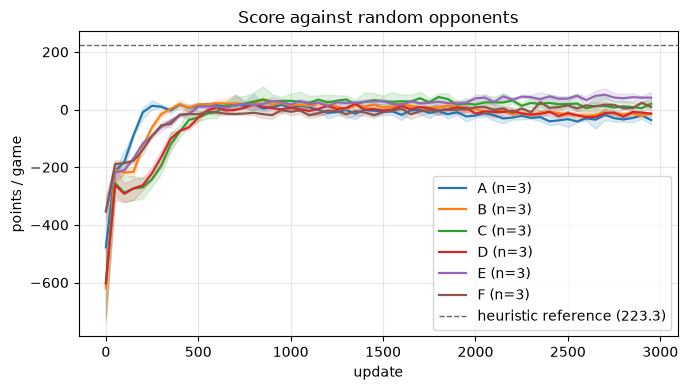

In [ ]:
# every configuration (+ heuristic) plays against 2x random
compare("score_vs_random", "Score against random opponents", "points / game",
        hline=223.3, hlabel="heuristic reference (223.3)")
plt.tight_layout(); plt.show()

heuristic at a table of heuristics: 187.51 +- 1.26 points/game


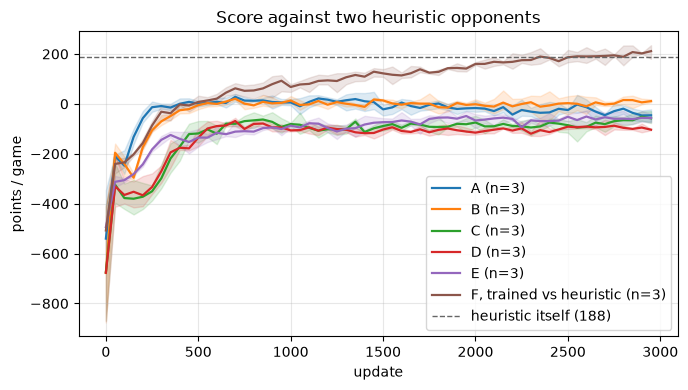

In [40]:
import random
import numpy as np

# same plot, now every configuration plays against 2x heuristic
def heuristic_baseline(n_games=5000, seed=5):
    """Points per game for a heuristic at a table of three heuristics.

    Averaged over all three seats -- seat 0 alone reads about 10 points low,
    because 20 rounds do not divide evenly by three. 5000 games because the
    value still swings by +-7 at 300. The heuristic never changes, so run it
    once: 187.6 +- 0.9.
    """
    random.seed(seed)
    points = []
    for _ in range(n_games):
        players = [Player(f"h{i}", i, HeuristicAgent()) for i in range(3)]
        game = Game()
        for p in players:
            game.add_player(p)
        game.start()
        points += [p.points for p in players]          # all three seats
    a = np.array(points, dtype=float)
    return float(a.mean()), float(a.std() / np.sqrt(len(a)))


baseline, baseline_se = heuristic_baseline()
print(f"heuristic at a table of heuristics: {baseline:.2f} +- {baseline_se:.2f} points/game")

ax = compare("score_vs_heuristic",
             "Score against two heuristic opponents", "points / game",
             hline=baseline, hlabel=f"heuristic itself ({baseline:.0f})")

handles, labels = ax.get_legend_handles_labels()
labels = [l.replace("F (", "F, trained vs heuristic (") for l in labels]
ax.legend(handles, labels)
plt.tight_layout()
plt.savefig("figures/score_against_heuristic.png", dpi=150)
plt.show()

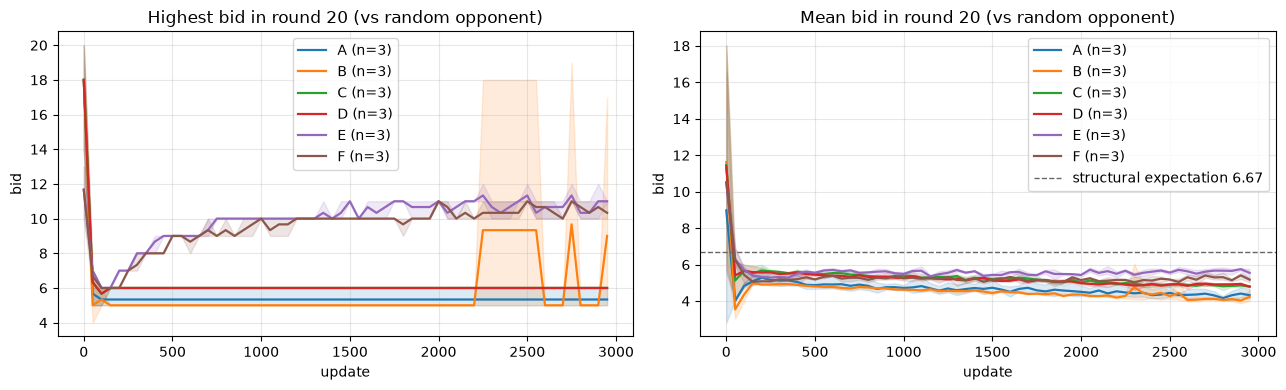

In [ ]:
# A / C / E: the bidding ceiling in round 20. This is the central pathology,
# and it now comes from the bids actually played, so it is comparable across
# the policy configurations and the EV one.
# Measured against random --> a random agent bids normally distributed with a mean of 10 in round 20,
# accordingly the RL has a mean below the expectancy of 6.67 as it corrects for this "good" (high) bidding of the random agent.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
compare("bids_max_r20", "Highest bid in round 20 (vs random opponent)", "bid", ax=axes[0])
compare("bids_mean_r20", "Mean bid in round 20 (vs random opponent)", "bid", ax=axes[1],
        hline=6.67, hlabel="structural expectation 6.67")
plt.tight_layout(); plt.show()

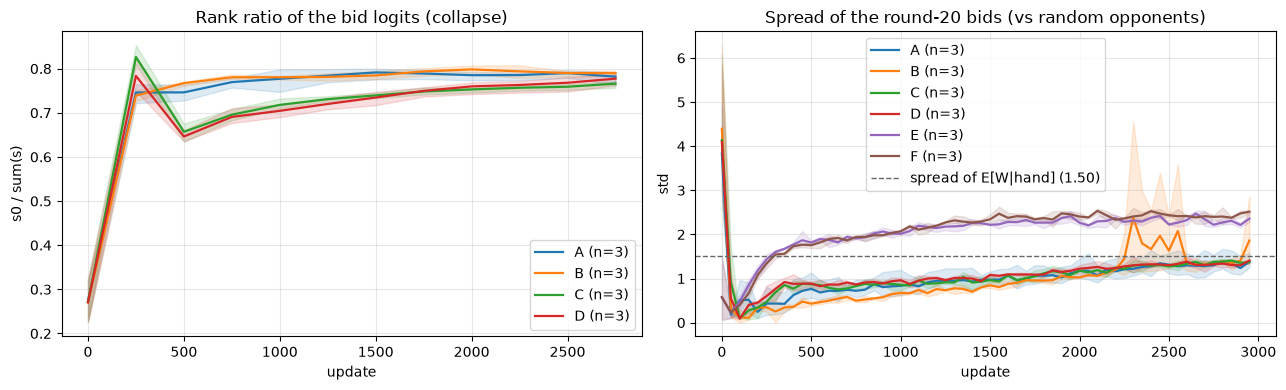

In [16]:
# B and C: does the collapse move? The rank ratio is the share of the bid
# logits' variation living in a single direction -- it rises as the head stops
# distinguishing hands. Only defined where the bid head is a policy.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
compare("rank_bid_all", "Rank ratio of the bid logits (collapse)", "s0 / sum(s)",
        configs="ABCD", ax=axes[0])
compare("bids_std_r20", "Spread of the round-20 bids (vs random opponents)", "std", ax=axes[1],
        hline=1.50, hlabel="spread of E[W|hand] (1.50)")
plt.tight_layout(); plt.show()

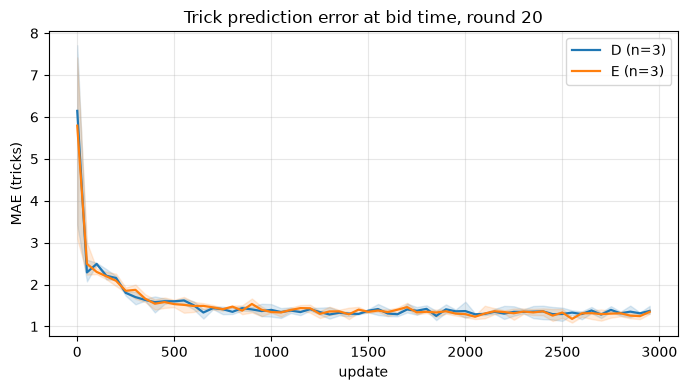

In [10]:
# D: how good is the tricks head at bid time? The bid in configuration E
# depends entirely on it.
compare("tricks_mae_r20_at_bid", "Trick prediction error at bid time, round 20",
        "MAE (tricks)", configs="DE")
plt.tight_layout(); plt.show()

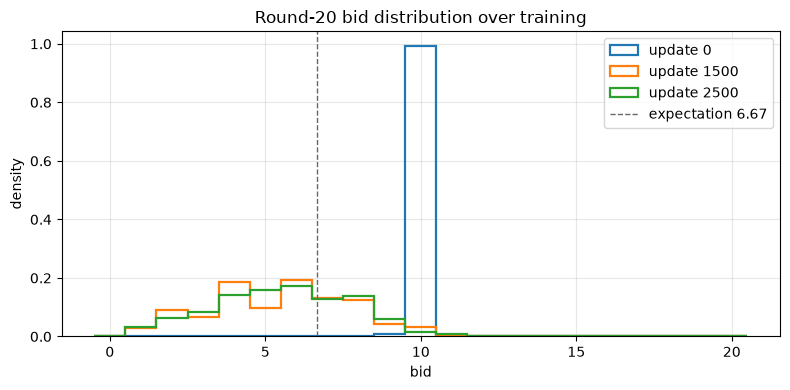

In [41]:
# E: the bid distribution over training. At update 0 the tricks head is
# uninformative, q is uniform, and the EV rule has a fixed point near 10 --
# that spike is a property of the scoring function, not a learned bid.
res = load_results(run_id("E", 0), result_dir=str(RESULTS))
if res and res["bids_r20"]:
    steps = sorted(res["bids_r20"], key=int)
    show = [steps[0]] + steps[len(steps)//2::max(1, len(steps)//3)]
    fig, ax = plt.subplots(figsize=(8, 4))
    for s in dict.fromkeys(show):
        ax.hist(res["bids_r20"][s], bins=np.arange(-0.5, 21.5), histtype="step",
                density=True, linewidth=1.6, label=f"update {s}")
    ax.axvline(6.67, ls="--", c="0.4", lw=1, label="expectation 6.67")
    ax.set_title("Round-20 bid distribution over training")
    ax.set_xlabel("bid"); ax.set_ylabel("density"); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()
else:
    print("no histograms yet -- they are written at every 250th update")

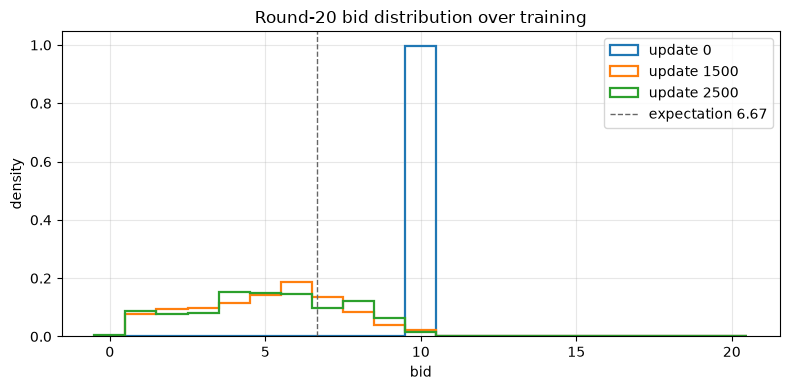

In [42]:
# F: the bid distribution over training. At update 0 the tricks head is
# uninformative, q is uniform, and the EV rule has a fixed point near 10 --
# that spike is a property of the scoring function, not a learned bid.
res = load_results(run_id("F", 0), result_dir=str(RESULTS))
if res and res["bids_r20"]:
    steps = sorted(res["bids_r20"], key=int)
    show = [steps[0]] + steps[len(steps)//2::max(1, len(steps)//3)]
    fig, ax = plt.subplots(figsize=(8, 4))
    for s in dict.fromkeys(show):
        ax.hist(res["bids_r20"][s], bins=np.arange(-0.5, 21.5), histtype="step",
                density=True, linewidth=1.6, label=f"update {s}")
    ax.axvline(6.67, ls="--", c="0.4", lw=1, label="expectation 6.67")
    ax.set_title("Round-20 bid distribution over training")
    ax.set_xlabel("bid"); ax.set_ylabel("density"); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()
else:
    print("no histograms yet -- they are written at every 250th update")

In [33]:
import json
import os

import torch

from model import WizNet
from player import Player, RLAgent, HeuristicAgent
from game import Game


def _load(name, update=2750, ckpt_dir="checkpoints", result_dir="results"):
    """(net, bid_mode) for one finished run, tolerating both naming schemes."""
    meta = json.load(open(os.path.join(result_dir, f"{name}.json")))
    ts = meta["run_name"][:15]
    for fname in (f"{name}_{ts}_up{update}.pt", f"up_{ts}_{update}.pt"):
        path = os.path.join(ckpt_dir, fname)
        if os.path.exists(path):
            net = WizNet(317, 20, 256)
            net.load_state_dict(torch.load(path, weights_only=True), strict=False)
            net.eval()
            return net, meta["config"]["bid_mode"]
    raise FileNotFoundError(f"no checkpoint for {name} at update {update}")


def selfplay_score(make_agent, n_games=600, seed=5):
    """Three copies of one policy at the same table.

    Immune to any contamination argument -- no foreign opponent takes part, so
    a configuration that trained against the heuristic gains nothing here. All
    three seats are counted, which is what makes it directly comparable to
    heuristic_baseline().
    """
    random.seed(seed); torch.manual_seed(seed)
    points, rows = [], []
    with torch.no_grad():
        for _ in range(n_games):
            players = [Player(f"p{i}", i, make_agent()) for i in range(3)]
            game = Game()
            for p in players:
                game.add_player(p)
            game.start()
            points += [p.points for p in players]
            rows += [x for p in players for x in p.round_log]

    a = np.array(points, dtype=float)
    r = np.array(rows, dtype=float)
    called, won = r[:, 1], r[:, 2]
    return dict(points=a.mean(), se=a.std() / np.sqrt(len(a)),
                hit=np.mean(called == won), mae=np.mean(abs(called - won)))


def selfplay_table(configs="ABCDEF", seeds=(0, 1, 2), n_games=600,
                   baseline=None, baseline_se=None):
    """Self-play score of every configuration, against the heuristic line."""
    print(f"{'':>10} {'points':>9} {'meas. err':>10} {'seed spread':>12} "
          f"{'hit':>7} {'MAE':>7}   individual seeds")
    print("-" * 88)

    if baseline is not None:
        se = f"+-{baseline_se:.2f}" if baseline_se else ""
        print(f"{'heuristic':>10} {baseline:9.2f} {se:>10} {'-':>12} "
              f"{'':>7} {'':>7}   <- the line to beat")
        print()

    out = {}
    for name in configs:
        runs = []
        for s in seeds:
            net, mode = _load(f"{name}_seed{s}")
            runs.append(selfplay_score(
                lambda net=net, mode=mode: RLAgent(net, greedy=True, bid_mode=mode),
                n_games=n_games))
        pts = np.array([r["points"] for r in runs])
        # measurement error of the mean over seeds, and the real spread between
        # training runs -- the second one is the honest error bar for "how good
        # is this configuration", the first only says how carefully we measured
        meas = float(np.sqrt(sum(r["se"] ** 2 for r in runs)) / len(runs))
        spread = float(pts.std())
        out[name] = dict(points=pts.mean(), meas=meas, spread=spread,
                         seeds=pts.tolist(),
                         hit=np.mean([r["hit"] for r in runs]),
                         mae=np.mean([r["mae"] for r in runs]))
        o = out[name]
        mark = " *" if baseline and o["points"] > baseline else ""
        print(f"{name:>10} {o['points']:9.2f} {'+-'+f'{meas:.2f}':>10} "
              f"{'+-'+f'{spread:.1f}':>12} {o['hit']:7.3f} {o['mae']:7.3f}   "
              f"{' '.join(f'{x:.0f}' for x in pts)}{mark}")

    if baseline:
        print("\n* beats the heuristic baseline")
    return out

In [34]:
# playing against itself
table = selfplay_table(baseline=baseline, baseline_se=baseline_se)

              points  meas. err  seed spread     hit     MAE   individual seeds
----------------------------------------------------------------------------------------
 heuristic    187.51     +-1.26            -                   <- the line to beat

         A    100.52     +-1.97        +-9.6   0.330   1.038   114 92 95
         B    158.72     +-2.02        +-6.7   0.374   0.972   150 161 165
         C    178.75     +-2.09       +-13.8   0.332   0.947   198 170 168
         D    137.04     +-2.04        +-4.2   0.298   1.020   131 140 140
         E    204.80     +-2.09        +-5.4   0.365   0.849   203 212 199 *
         F    220.62     +-2.09       +-12.1   0.382   0.819   212 212 238 *

* beats the heuristic baseline


How does every configuration performs in self-play? The table shows that the heuristic achieves roughly 187 points, while RL configuration F performs best.

In [ ]:
import random, numpy as np
from player import Player, HeuristicAgent
from game import Game

# how stable/reliable are the heuristics scores when it plays against itself?
def baseline(n_games, seed):
    random.seed(seed); pts=[]
    for _ in range(n_games):
        ps=[Player(f"h{i}",i,HeuristicAgent()) for i in range(3)]
        g=Game()
        for p in ps: g.add_player(p)
        g.start(); pts += [p.points for p in ps]
    return float(np.mean(pts))

# calculate the true self-play points for 3 heuristics playing each other
print(f"{'games':>8} {'mean':>8} {'std':>10} {'range':>16}")
for n in (100, 300, 1000, 5000):
    v = np.array([baseline(n, s) for s in range(10)])
    print(f"{n:8d} {v.mean():8.1f} {'+-'+f'{v.std():.1f}':>10} {f'{v.min():.0f} - {v.max():.0f}':>16}")

   games     mean        std            range
     100    183.3     +-12.0        168 - 203
     300    185.7      +-6.6        178 - 202
    1000    187.2      +-3.1        182 - 194
    5000    187.6      +-0.9        186 - 189


## 4 — Table for the README

The numbers behind the Experiments section, taken from the last eval point of
each run.

In [46]:
import json
import os
import random

import numpy as np
import torch

from game import Game
from model import WizNet
from player import HeuristicAgent, Player, RLAgent

RESULT_DIR = "results"
CKPT_DIR = "checkpoints"
SEEDS = (0, 1, 2)


def load_run(name, update=2750):
    """(net, bid_mode, history) for one finished run."""
    meta = json.load(open(os.path.join(RESULT_DIR, f"{name}.json")))
    ts = meta["run_name"][:15]
    for fname in (f"{name}_{ts}_up{update}.pt", f"up_{ts}_{update}.pt"):
        path = os.path.join(CKPT_DIR, fname)
        if os.path.exists(path):
            net = WizNet(317, 20, 256)
            net.load_state_dict(torch.load(path, weights_only=True), strict=False)
            net.eval()
            return net, meta["config"]["bid_mode"], meta["history"]
    raise FileNotFoundError(f"no checkpoint for {name} at update {update}")


def table_score(make_agent, n_games=600, seed=5):
    """Points, hit rate and MAE for three copies of one policy at one table.

    All three seats count: 20 rounds do not divide evenly by three, so seats
    differ by ~27 points even for identical policies.
    """
    random.seed(seed); torch.manual_seed(seed)
    points, rows = [], []
    with torch.no_grad():
        for _ in range(n_games):
            players = [Player(f"p{i}", i, make_agent()) for i in range(3)]
            game = Game()
            for p in players:
                game.add_player(p)
            game.start()
            points += [p.points for p in players]
            rows += [x for p in players for x in p.round_log]

    pts = np.array(points, dtype=float)
    r = np.array(rows, dtype=float)
    return dict(points=pts.mean(), se=pts.std() / np.sqrt(len(pts)),
                hit=np.mean(r[:, 1] == r[:, 2]), mae=np.mean(abs(r[:, 1] - r[:, 2])))


def heuristic_baseline(n_games=5000, seed=5):
    """Baseline: a heuristic at a table of heuristics. 187.6 +- 0.9."""
    return table_score(HeuristicAgent, n_games=n_games, seed=seed)


def summary_table(configs="ABCDEF", seeds=SEEDS, n_games=600, baseline=None):
    """Final results table.

    Bid statistics come from self-play, not from the result files: the ones
    logged during training were measured against RandomAgent, which bids ~10
    in round 20 and drags the agent's bid down with it.
    """
    train_keys = [("score_vs_random", "vs random"),
                  ("score_vs_heuristic", "vs heuristic"),
                  ("tricks_mae_r20_at_bid", "tricks MAE")]

    hdr = (f"{'cfg':<5}" + "".join(f"{lbl:>16}" for _, lbl in train_keys)
           + f"{'self-play':>16}{'hit':>9}{'MAE':>9}")
    print(hdr); print("-" * len(hdr))
    if baseline:
        print(f"{'heur':<5}{'':>48}{baseline['points']:>16.1f}"
              f"{baseline['hit']:>9.3f}{baseline['mae']:>9.3f}   <- baseline\n")

    out = {}
    for name in configs:
        runs, hists = [], []
        for s in seeds:
            net, mode, hist = load_run(f"{name}_seed{s}")
            hists.append(hist)
            runs.append(table_score(
                lambda net=net, mode=mode: RLAgent(net, greedy=True, bid_mode=mode),
                n_games=n_games))

        row = f"{name:<5}"
        for key, _ in train_keys:
            vals = [h[-1][key] for h in hists if key in h[-1]]
            row += (f"{np.mean(vals):>10.2f}+-{np.std(vals):<4.1f}" if len(vals) > 1
                    else f"{vals[0]:>16.2f}" if vals else f"{'-':>16}")

        pts = np.array([r["points"] for r in runs])
        out[name] = dict(points=pts.mean(), spread=pts.std(), seeds=pts.tolist(),
                         hit=np.mean([r["hit"] for r in runs]),
                         mae=np.mean([r["mae"] for r in runs]))
        o = out[name]
        mark = " *" if baseline and o["points"] > baseline["points"] else ""
        row += f"{o['points']:>10.1f}+-{o['spread']:<4.0f}{o['hit']:>9.3f}{o['mae']:>9.3f}{mark}"
        print(row)

    if baseline:
        print("\n* beats the heuristic baseline"
              f"   |   self-play error bars are the spread over {len(seeds)} seeds")
    return out

In [ ]:
# the final, compact results table over all configuration to easily compare scores
baseline = heuristic_baseline()
print(f"baseline: {baseline['points']:.1f} +- {baseline['se']:.1f}\n")

results = summary_table(baseline=baseline)

baseline: 187.5 +- 1.3

cfg         vs random    vs heuristic      tricks MAE       self-play      hit      MAE
---------------------------------------------------------------------------------------
heur                                                            187.5    0.370    0.921   <- baseline

A        -36.28+-12.8    -45.90+-20.2      3.49+-1.0      100.5+-10      0.330    1.038


## analysis of agent behavior in round 20 against different opponents

In [44]:
import collections
import random

import numpy as np
import torch

from game import Game
from model import WizNet
from player import HeuristicAgent, Player, RandomAgent, RLAgent


def load_net(ckpt, obs_dim=317, max_bid=20, hidden_dim=256):
    net = WizNet(obs_dim, max_bid, hidden_dim)
    net.load_state_dict(torch.load(ckpt, weights_only=True), strict=False)
    net.eval()
    return net


def _spy(bid_mode):
    """RLAgent that records its round-20 bidding decisions."""
    class Spy(RLAgent):
        def __init__(self, net):
            super().__init__(net, greedy=True, bid_mode=bid_mode)
            self.log = []
        def choose_bid(self, obs, valid_bids):
            b = super().choose_bid(obs, valid_bids)
            if obs.round_nr == 20:
                # index 0 of bids_and_wins is me, 1 and 2 are the others
                others = [obs.bids_and_wins[i][0] for i in (1, 2)
                          if obs.bids_and_wins[i][0] is not None]
                self.log.append((obs.n_players_bid_before_me, b, others))
            return b
    return Spy


def _play(net, make_opponent, bid_mode, n_games, seed):
    """n games with the measured agent rotating through all three seats."""
    Spy = _spy(bid_mode)
    random.seed(seed); torch.manual_seed(seed)
    measured = []
    with torch.no_grad():
        for g_i in range(n_games):
            seat = g_i % 3
            opp_seats = [i for i in range(3) if i != seat]
            seats = [None, None, None]
            seats[seat] = Player("rl", seat, Spy(net))
            for k, i in enumerate(opp_seats):
                seats[i] = Player(f"o{k}", i, make_opponent())
            game = Game()
            for p in seats:
                game.add_player(p)
            game.start()
            measured.append((seats[seat], [seats[i] for i in opp_seats]))
    return measured


# --- Analysis 1: what the agent bids against which opponent -----------------

def bid_by_opponent(ckpt, bid_mode="ev", n_games=240, seed=42):
    """Round-20 bidding against random, heuristic and self opponents.

    The random axis is the one TensorBoard plots as bids/mean_r20_random, and
    it does not measure calibration: RandomAgent bids uniformly over 0..r, so
    each opponent announces ~10 of the 20 tricks available in round 20. The
    agent reads those bids from its observation and lowers its own.
    """
    net = load_net(ckpt)
    tables = {"2x random":    RandomAgent,
              "2x heuristic": HeuristicAgent,
              "2x self":      lambda: RLAgent(net, greedy=True, bid_mode=bid_mode)}

    print(f"{ckpt}\n")
    print(f"{'measured against':>18} {'opp bids':>9} {'agent bids':>11} "
          f"{'wins':>7} {'bias':>7}   {'by position 0/1/2':>20}")
    rows = {}
    for label, make_opp in tables.items():
        played = _play(net, make_opp, bid_mode, n_games, seed)
        log = [e for agent, _ in played for e in agent.agent.log]
        won20 = [w for agent, _ in played
                 for (r, c, w) in agent.round_log if r == 20]

        bids = np.array([b for _, b, _ in log], dtype=float)
        opp_bids = [x for _, _, others in log for x in others]
        by_pos = collections.defaultdict(list)
        for nb, b, _ in log:
            by_pos[nb].append(b)
        pos = " / ".join(f"{np.mean(by_pos[p]):.2f}" for p in sorted(by_pos))

        rows[label] = dict(opp=np.mean(opp_bids), bid=bids.mean(),
                           won=np.mean(won20), by_pos=pos)
        print(f"{label:>18} {rows[label]['opp']:9.2f} {bids.mean():11.2f} "
              f"{np.mean(won20):7.2f} {bids.mean()-np.mean(won20):+7.2f}   {pos:>20}")
    return rows


# --- Analysis 2: bid quality at the same table ------------------------------

def head_to_head(ckpt, bid_mode="ev", n_games=200, seed=11):
    """One RL agent against two heuristics: same deals, same conditions.

    Separates bidding quality from playing strength -- both sides face
    identical cards, so any difference in hit rate is theirs.
    """
    net = load_net(ckpt)
    played = _play(net, HeuristicAgent, bid_mode, n_games, seed)

    rows = {"RL": [], "heuristic": []}
    points = {"RL": [], "heuristic": []}
    for agent, opps in played:
        rows["RL"] += agent.round_log
        points["RL"].append(agent.points)
        for o in opps:
            rows["heuristic"] += o.round_log
            points["heuristic"].append(o.points)

    print(f"{ckpt}\n")
    print(f"{'':>10} {'hit rate':>9} {'MAE':>7} {'bias':>7} {'corr':>7} "
          f"{'hit r>=14':>10} {'points':>8}")
    out = {}
    for who in ("RL", "heuristic"):
        a = np.array(rows[who], dtype=float)
        r, c, w = a[:, 0], a[:, 1], a[:, 2]
        big = r >= 14
        out[who] = dict(hit=np.mean(c == w), mae=np.mean(abs(c - w)),
                        bias=np.mean(c - w), corr=np.corrcoef(c, w)[0, 1],
                        hit_big=np.mean(c[big] == w[big]),
                        points=np.mean(points[who]))
        o = out[who]
        print(f"{who:>10} {o['hit']:9.3f} {o['mae']:7.3f} {o['bias']:+7.3f} "
              f"{o['corr']:7.3f} {o['hit_big']:10.3f} {o['points']:8.1f}")
    return out

In [45]:
# run analysis

E = "checkpoints/E_seed2_20260907_190730_up2750.pt"
F = "checkpoints/F_seed2_20260907_190730_up2750.pt"

for ckpt in (E, F):
    bid_by_opponent(ckpt)
    print()

for ckpt in (E, F):
    head_to_head(ckpt)
    print()

checkpoints/E_seed2_20260907_190730_up2750.pt

  measured against  opp bids  agent bids    wins    bias      by position 0/1/2
         2x random      9.60        5.50    6.54   -1.04     6.51 / 5.85 / 4.14
      2x heuristic      5.35        7.06    4.49   +2.58     6.81 / 7.05 / 7.33
           2x self      6.66        6.79    6.72   +0.07     6.81 / 6.88 / 6.69

checkpoints/F_seed2_20260907_190730_up2750.pt

  measured against  opp bids  agent bids    wins    bias      by position 0/1/2
         2x random     10.20        5.20    6.97   -1.77     6.78 / 5.39 / 3.45
      2x heuristic      5.35        7.00    6.89   +0.10     6.71 / 7.06 / 7.21
           2x self      6.63        6.67    6.71   -0.05     6.71 / 6.86 / 6.42

checkpoints/E_seed2_20260907_190730_up2750.pt

            hit rate     MAE    bias    corr  hit r>=14   points
        RL     0.262   1.347  +1.029   0.787      0.104    -48.8
 heuristic     0.352   1.057  -0.566   0.869      0.264    136.5

checkpoints/F_seed2_2